# Gaussian Naive Bayes Classification


Example Predictions:
Actual: versicolor, Predicted: versicolor
Actual: setosa, Predicted: setosa
Actual: virginica, Predicted: virginica
Actual: versicolor, Predicted: versicolor
Actual: versicolor, Predicted: versicolor

Confusion Matrix:


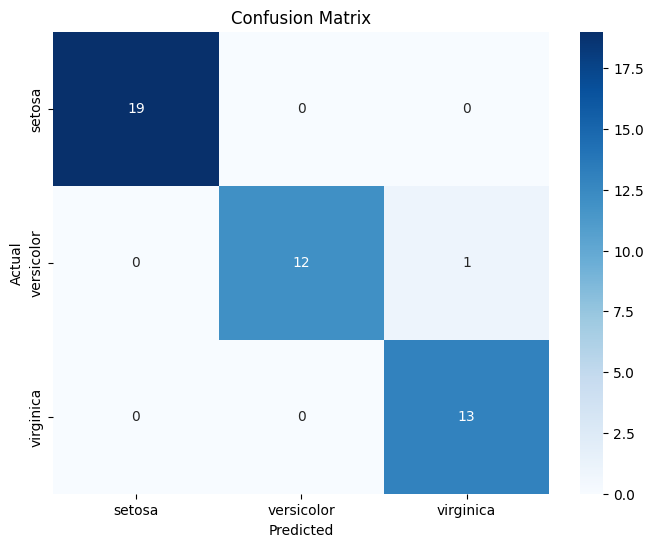



=============== CLASSIFICATION REPORT =============== 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.92      1.00      0.96        12
           2       1.00      0.93      0.96        14

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.97        45
weighted avg       0.98      0.98      0.98        45



In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

iris = load_iris()

X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Display some example predictions
print("Example Predictions:")
for i in range(5):
    print(f"Actual: {iris.target_names[y_test[i]]}, Predicted: {iris.target_names[y_pred[i]]}")

conf_matrix = confusion_matrix(y_test, y_pred)

# Display confusion matrix with labels
print("\nConfusion Matrix:")
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print('\n')
print("=============== CLASSIFICATION REPORT =============== ")
print(classification_report(y_pred, y_test))

# Multinomial Naive Bayes Classification

,Category,Message,label
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


,00,000,000pes,008704050406,0089,0121,01223585236,01223585334,0125698789,02,...,zeros,zhong,zindgi,zoe,zogtorius,zoom,zouk,zyada,ãº1,ã¼
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Shape of X_train: (3900, 8745)
Shape of X_test: (1672, 8745)
Shape of y_train: (3900,)
Shape of y_test: (1672,)

Confusion Matrix:


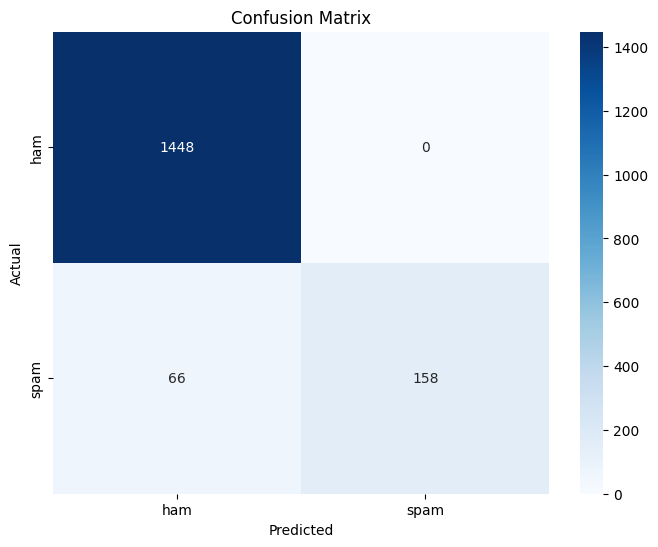

Example Predictions:
Message: Squeeeeeze!! This is christmas hug.. If u lik my frndshp den hug me back.. If u get 3 u r cute:) 6 u r luvd:* 9 u r so lucky;) None? People hate u:
Actual: ham, Predicted: ham

Message: And also I've sorta blown him off a couple times recently so id rather not text him out of the blue looking for weed
Actual: ham, Predicted: ham

Message: Mmm thats better now i got a roast down me! iÂd b better if i had a few drinks down me 2! Good indian?
Actual: ham, Predicted: ham

Message: Mm have some kanji dont eat anything heavy ok
Actual: ham, Predicted: ham

Message: So there's a ring that comes with the guys costumes. It's there so they can gift their future yowifes. Hint hint
Actual: ham, Predicted: ham

Message: Sary just need Tim in the bollox &it hurt him a lot so he tol me!
Actual: ham, Predicted: ham

Message: Love isn't a decision, it's a feeling. If we could decide who to love, then, life would be much simpler, but then less magical
Actual: ham, Predicte

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

spam_df = pd.read_csv('/content/sample_data/spam.csv', encoding='latin-1')
spam_df['label'] = spam_df['Category'].map({'ham': 0, 'spam': 1})

tfidf_vectorizer = TfidfVectorizer()
X = tfidf_vectorizer.fit_transform(spam_df['Message'])

X_df = pd.DataFrame(X.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

display(spam_df.head())
display(X_df.head())

X = X_df
y = spam_df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

example_predictions = []
test_indices = y_test.index

label_map = {0: 'ham', 1: 'spam'}

for i in range(min(10, len(test_indices))):
    original_index = test_indices[i]
    original_message = spam_df.loc[original_index, 'Message']
    actual_label = label_map[y_test.iloc[i]]
    predicted_label = label_map[y_pred[i]]

    example_predictions.append({
        'Original Message': original_message,
        'Actual Label': actual_label,
        'Predicted Label': predicted_label
    })

print("Example Predictions:")
for example in example_predictions:
    print(f"Message: {example['Original Message']}")
    print(f"Actual: {example['Actual Label']}, Predicted: {example['Predicted Label']}\n")

print('\n')
print("=============== CLASSIFICATION REPORT =============== ")
print(classification_report(y_pred, y_test))


# Bernoulli Naive Bayes Classification

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


,Category,Message,label
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0



Shape of X_binarized: (5572, 8745)
Shape of X_train: (3900, 8745)
Shape of X_test: (1672, 8745)
Shape of y_train: (3900,)
Shape of y_test: (1672,)
Predictions made successfully.

Confusion Matrix:


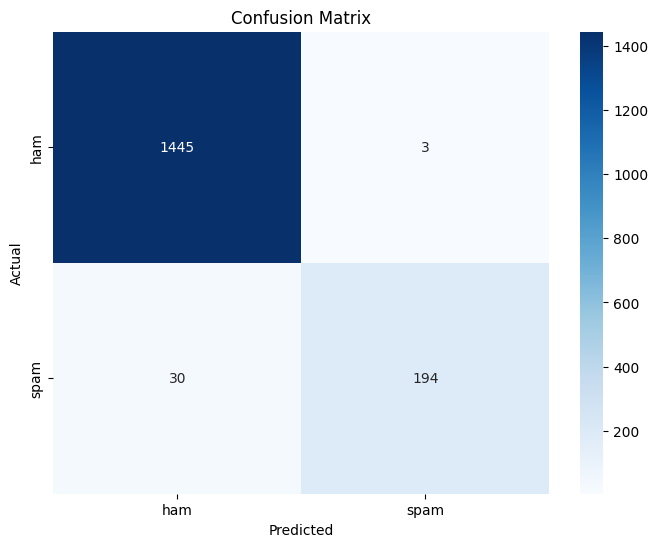

Example Predictions:
Message: Squeeeeeze!! This is christmas hug.. If u lik my frndshp den hug me back.. If u get 3 u r cute:) 6 u r luvd:* 9 u r so lucky;) None? People hate u:
Actual: ham, Predicted: ham

Message: And also I've sorta blown him off a couple times recently so id rather not text him out of the blue looking for weed
Actual: ham, Predicted: ham

Message: Mmm thats better now i got a roast down me! iÂd b better if i had a few drinks down me 2! Good indian?
Actual: ham, Predicted: ham

Message: Mm have some kanji dont eat anything heavy ok
Actual: ham, Predicted: ham

Message: So there's a ring that comes with the guys costumes. It's there so they can gift their future yowifes. Hint hint
Actual: ham, Predicted: ham

Message: Sary just need Tim in the bollox &it hurt him a lot so he tol me!
Actual: ham, Predicted: ham

Message: Love isn't a decision, it's a feeling. If we could decide who to love, then, life would be much simpler, but then less magical
Actual: ham, Predicte

In [ ]:
from sklearn.naive_bayes import BernoulliNB

spam_df = pd.read_csv('/content/sample_data/spam.csv', encoding='latin-1')
display(spam_df.head())

spam_df['label'] = spam_df['Category'].map({'ham': 0, 'spam': 1})

tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(spam_df['Message'])

X_dense = X_tfidf.toarray()

X_binarized = (X_dense > 0).astype(int)

display(spam_df.head())
print("\nShape of X_binarized:", X_binarized.shape)

X = X_binarized
y = spam_df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

model = BernoulliNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Predictions made successfully.")

conf_matrix = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

example_predictions = []
test_indices = y_test.index

label_map = {0: 'ham', 1: 'spam'}

for i in range(min(10, len(test_indices))):
    original_index = test_indices[i]
    original_message = spam_df.loc[original_index, 'Message']
    actual_label = label_map[y_test.iloc[i]]
    predicted_label = label_map[y_pred[i]]

    example_predictions.append({
        'Original Message': original_message,
        'Actual Label': actual_label,
        'Predicted Label': predicted_label
    })

print("Example Predictions:")
for example in example_predictions:
    print(f"Message: {example['Original Message']}")
    print(f"Actual: {example['Actual Label']}, Predicted: {example['Predicted Label']}\n")

print('\n')
print("=============== CLASSIFICATION REPORT =============== ")
print(classification_report(y_pred, y_test))